In [1]:
import sys
sys.path.append(r"C:\nirfasterFF")
import nirfasterff as ff # ff is short for fast and furious
import numpy as np
import matplotlib.pyplot as plt

In [2]:
mua = 0.01
mus = 0.33 # approx same as musp here
ri = 1.33
mua_pert_percent = 0.01
mus_pert_percent = 0.01

In [3]:
vol = 2 * np.ones((60,60,60))
vol = vol.astype(np.uint8)

meshing_params = ff.utils.MeshingParams(
    xPixelSpacing=0.5,  # Finer voxel resolution
    yPixelSpacing=0.5,
    SliceThickness=0.5,
    general_cell_size=1.0,  # Smaller elements
    cell_radius_edge=2.0,  # Better element quality
    facet_size=1.5,  # More refined surface
    facet_distance=1.0
)
# call the mesher
ele, nodes = ff.meshing.RunCGALMeshGenerator(vol, opt = meshing_params)

In [4]:
mesh = ff.base.stndmesh()
mesh.from_solid(ele, nodes)

# for each row, [region, mua(mm-1), musp(mm-1), ri]
prop = np.array([[1, mua, mus, ri]])
mesh.set_prop(prop)
mesh.kappa = 1 / (3*(mesh.mua + mesh.mus))
# set link (source-detector pairs)
mesh.link = np.array([[1,1,1]],dtype=np.int32)
# optodes
mesh.source = ff.base.optode(np.array([3,30,60]))
mesh.meas = ff.base.optode(np.array([57,30,60]))
# move them (for non-fixed) and calculate the integration function
mesh.touch_optodes()

touching sources
touching detectors


Create grid space

In [5]:
xgrid = np.arange(0., 60, 0.5)
ygrid = np.arange(0., 60, 0.5)
zgrid = np.arange(0., 60, 0.5)

mesh.gen_intmat(xgrid, ygrid, zgrid)

#### TEST 1: comparing [mua-Perturbation method-doD    vs     mua-jacobian method-doD] for DC mesh

In [6]:
#Scan parameters
start = 10
stop = 50
step = 10

In [ ]:
J_mua_dc = mesh.jacobian(normalize=False)[0]     # mua-Jacobian of main mesh

data_dc = mesh.femdata(0)[0]                     #  measured DC boundary data
data_dc = data_dc.amplitude

# creating duplicate of mesh for measuring US-perturbed-perturbation-model doD
mesh2 = ff.base.stndmesh()

doD_mua_pert = np.zeros(stop+1)
doD_mua_jacobian = np.zeros(stop+1)
error_mua = np.zeros(stop+1)

print('\n')

for i in range(start,stop+1,step):
   mesh2.from_copy(mesh)       # mua of mesh2 is same as mesh1.mua, ie equal to 'mesh.mua + mesh.mus*ht' since it is derived from mesh1
   


   # add a spherical absorption inclusion in mesh2
   dia_ab =  6   #diameter of spherical absorber
   x_cen_ab,y_cen_ab,z_cen_ab = [30,30,i]      #centre of the absorber
   dist_ab = np.sqrt(np.square((mesh.nodes[:,0]-x_cen_ab)) + np.square((mesh.nodes[:,1]-y_cen_ab)) + np.square((mesh.nodes[:,2]-z_cen_ab)))
   ind_ab = dist_ab < dia_ab/2
   mua_selection = np.where(ind_ab)           #of all node points, this is the selection of nodes where the absorber inclusion exists



   # Modify the mua-map of mesh2(in mesh-space) by some percentage, and calculate the forward data and sebsequently the perturbation doD
   mesh2.mua[mua_selection] = mesh2.mua[mua_selection] + mua_pert_percent*mesh2.mua[mua_selection] 
   mesh2.kappa[mua_selection] = 1.0 / (3.0*(mesh2.mua[mua_selection] + mesh2.mus[mua_selection]))
   data_mesh2 = mesh2.femdata(0)[0] 
   data_mesh2 = data_mesh2.amplitude


   doD_mua_pert[i] = (data_mesh2 - data_dc).item()
  

   # Now calculate doD using the Jacobian method
   # creating the difference in absorption for selected nodes(to be multiplied with mua-Jacobian) in mesh-space and then interpolated to grid-space 
   tmp1= np.zeros(len(mesh.nodes))    #all meshes are derived from the original main 'mesh', hence its alright to use 'mesh.nodes'
   tmp1[mua_selection] = mua_pert_percent*mesh.mua[mua_selection]         # this is the effective difference in abs (in mesh-space). a 1% change in 'just absorption' 
   dmua = mesh.vol.mesh2grid@tmp1     # mesh to grid interpolation (difference in abs in grid-space) - (1728000,1)
   doD_mua_jacobian[i] = (J_mua_dc @ dmua).item()

   error_mua[i] = (((doD_mua_jacobian[i]-doD_mua_pert[i])/doD_mua_pert[i])*100)

   #Compare
   print(f"doD from US-perturbed-absorption-blob-perturbation model at z = {60-i} mm:", doD_mua_pert[i])
   print(f"doD from US-perturbed-absorption-blob-Jacobian: model at z = {60-i} mm:", doD_mua_jacobian[i])
   print('percentage error:' , (error_mua[i]))
   print('\n')

Calculating direct field...
Calculating adjoint field...
Integrating...


doD from US-perturbed-absorption-blob-perturbation model at z = 50 mm: -7.871323527057581e-14
doD from US-perturbed-absorption-blob-Jacobian: model at z = 50 mm: -8.147724120625351e-14
percentage error: 3.5114881584735547


doD from US-perturbed-absorption-blob-perturbation model at z = 40 mm: -8.001163050784551e-13
doD from US-perturbed-absorption-blob-Jacobian: model at z = 40 mm: -8.153082383998521e-13
percentage error: 1.898715627337128


doD from US-perturbed-absorption-blob-perturbation model at z = 30 mm: -5.787506684443497e-12
doD from US-perturbed-absorption-blob-Jacobian: model at z = 30 mm: -5.772699852274599e-12
percentage error: -0.25584129705972114


doD from US-perturbed-absorption-blob-perturbation model at z = 20 mm: -3.212941102303013e-11
doD from US-perturbed-absorption-blob-Jacobian: model at z = 20 mm: -3.104393265580455e-11
percentage error: -3.3784570979141706


doD from US-perturbed-absorp

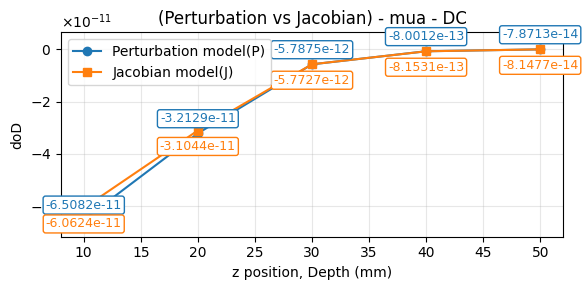

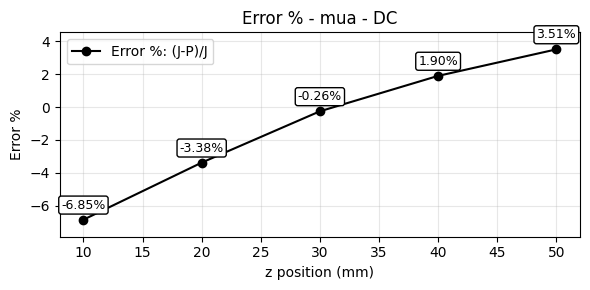

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Data
i = 10
z_positions = [i, 2*i, 3*i, 4*i, 5*i]
x = np.array(z_positions, dtype=float)
y_pert = np.array([doD_mua_pert[60-i],doD_mua_pert[60-2*i],doD_mua_pert[60-3*i],doD_mua_pert[60-4*i],doD_mua_pert[60-5*i]], dtype=float)
y_jac  = np.array([doD_mua_jacobian[60-i],doD_mua_jacobian[60-2*i],doD_mua_jacobian[60-3*i],doD_mua_jacobian[60-4*i],doD_mua_jacobian[60-5*i]], dtype=float)

# Plot
plt.figure(figsize=(6, 3))
line1, = plt.plot(x, y_pert, marker='o', linewidth=1.5, label='Perturbation model(P)')
line2, = plt.plot(x, y_jac,  marker='s', linewidth=1.5, label='Jacobian model(J)')

# Scientific notation for small values
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))

# Zoom y-limits with padding
y_min = min(np.min(y_pert), np.min(y_jac))
y_max = max(np.max(y_pert), np.max(y_jac))
pad = 0.1 * (y_max - y_min)
plt.ylim(y_min - pad, y_max + pad)

# Annotations: values at each point, colored by series and offset to avoid overlap
c1 = line1.get_color()
c2 = line2.get_color()

for xi, yi in zip(x, y_pert):
    ax.annotate(f'{yi:.4e}', (xi, yi),
                textcoords='offset points', xytext=(0, 8), ha='center',
                color=c1, fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=c1, alpha=1))

for xi, yi in zip(x, y_jac):
    ax.annotate(f'{yi:.4e}', (xi, yi),
                textcoords='offset points', xytext=(0, -14), ha='center',
                color=c2, fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=c2, alpha=1))

plt.xlabel('z position, Depth (mm)')
plt.ylabel('doD')
plt.title('(Perturbation vs Jacobian) - mua - DC')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()




# Error Plot
y_error = np.array([error_mua[60-i],error_mua[60-2*i],error_mua[60-3*i],error_mua[60-4*i],error_mua[60-5*i]])

plt.figure(figsize=(6, 3))
line_err, = plt.plot(x, y_error, marker='o', linewidth=1.5, color='black', label='Error %: (J-P)/J')

# Zoom in around the min/max range with 10% padding
y_min = np.min(y_error)
y_max = np.max(y_error)
pad = 0.1 * (y_max - y_min)
plt.ylim(y_min - pad, y_max + pad)

# Get the line color
c_err = line_err.get_color()

# Annotate each point
for xi, yi in zip(x, y_error):
    plt.annotate(f'{yi:.2f}%', (xi, yi),
                 textcoords='offset points', xytext=(0, 8), ha='center',
                 color=c_err, fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=c_err, alpha=1))

plt.xlabel('z position (mm)')
plt.ylabel('Error %')
plt.title('Error % - mua - DC')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



#### TEST 2: comparing [mus-Perturbation method-doD    vs     mua-jacobian method-doD] for DC mesh

In [8]:
#Scan parameters
start = 10
stop = 50
step = 10

In [ ]:
J_mus_dc = mesh.jacobian(normalize=False,mus=True)[0]     # mua-Jacobian of main mesh
J_mus_dc = J_mus_dc[:,:xgrid.size * ygrid.size * zgrid.size]    #(1, 1728000) # extracting just the mus part of the jacobian

data_dc = mesh.femdata(0)[0]                     # measured DC boundary data 
data_dc = data_dc.amplitude

# creating duplicate of mesh for measuring mus-perturbed-perturbation-model doD
mesh2 = ff.base.stndmesh()

doD_mus_pert = np.zeros(stop+1)
doD_mus_jacobian = np.zeros(stop+1)
error_mus = np.zeros(stop+1)

print('\n')

for i in range(start,stop+1,step):
   mesh2.from_copy(mesh)       # mua of mesh2 is same as mesh1.mua, ie equal to 'mesh.mua + mesh.mus*ht' since it is derived from mesh1
   


   # add a spherical absorption inclusion in mesh2
   dia_sc =  6   #diameter of spherical absorber
   x_cen_sc,y_cen_sc,z_cen_sc = [30,30,i]      #centre of the absorber
   dist_sc = np.sqrt(np.square((mesh.nodes[:,0]-x_cen_sc)) + np.square((mesh.nodes[:,1]-y_cen_sc)) + np.square((mesh.nodes[:,2]-z_cen_sc)))
   ind_sc = dist_sc < dia_sc/2
   mus_selection = np.where(ind_sc)           #of all node points, this is the selection of nodes where the absorber inclusion exists



   # Modify the mus-map of mesh2(in mesh-space) by some percentage, and calculate the forward data and sebsequently the perturbation doD
   mesh2.mus[mus_selection] = mesh.mus[mus_selection] + mus_pert_percent*mesh.mus[mus_selection] 
   mesh2.kappa[mus_selection] = 1.0 / (3.0*(mesh2.mua[mus_selection] + mesh2.mus[mus_selection]))
   data_mesh2 = mesh2.femdata(0)[0] 
   data_mesh2 = data_mesh2.amplitude

   doD_mus_pert[i] = (data_mesh2 - data_dc).item()
  


   # Now calculate doD using the Jacobian method
   # creating the difference in absorption for selected nodes(to be multiplied with mua-Jacobian) in mesh-space and then interpolated to grid-space 
   tmp1= np.zeros(len(mesh.nodes))    #all meshes are derived from the original main 'mesh', hence its alright to use 'mesh.nodes'
   tmp1[mus_selection] = mus_pert_percent*mesh.mus[mus_selection]         # this is the effective difference in abs (in mesh-space). a 1% change in 'just absorption' 
   dmus = mesh.vol.mesh2grid@tmp1     # mesh to grid interpolation (difference in abs in grid-space) - (1728000,1)
   doD_mus_jacobian[i] = (J_mus_dc @ dmus).item()

   
   error_mus[i] = (((doD_mus_jacobian[i]-doD_mus_pert[i])/doD_mus_pert[i])*100)


   #Compare
   print(f"doD from US-perturbed-absorption-blob-perturbation model at z = {60-i} mm:", doD_mus_pert[i])
   print(f"doD from US-perturbed-absorption-blob-Jacobian: model at z = {60-i} mm:", doD_mus_jacobian[i])
   print('percentage error_mus:' , error_mus[i])
   print('\n')


Calculating direct field...
Calculating adjoint field...
Integrating...


C:\nirfasterFF\nirfasterff\math.py:759: RuntimeWarning: invalid value encountered in divide
  int_func_tmp /= int_func_tmp.sum()




doD from US-perturbed-absorption-blob-perturbation model at z = 50 mm: 8.832539162579721e-14
doD from US-perturbed-absorption-blob-Jacobian: model at z = 50 mm: 8.90053249824994e-14
percentage error_mus: 0.7698050857026679


doD from US-perturbed-absorption-blob-perturbation model at z = 40 mm: 4.987397829125692e-13
doD from US-perturbed-absorption-blob-Jacobian: model at z = 40 mm: 5.023065339402627e-13
percentage error_mus: 0.7151527008461471


doD from US-perturbed-absorption-blob-perturbation model at z = 30 mm: -3.8144774956249907e-13
doD from US-perturbed-absorption-blob-Jacobian: model at z = 30 mm: -3.6634667826956945e-13
percentage error_mus: -3.958883309771725


doD from US-perturbed-absorption-blob-perturbation model at z = 20 mm: -3.613606313604071e-11
doD from US-perturbed-absorption-blob-Jacobian: model at z = 20 mm: -3.6470338732307177e-11
percentage error_mus: 0.9250470783384122


doD from US-perturbed-absorption-blob-perturbation model at z = 10 mm: -1.43662024726899

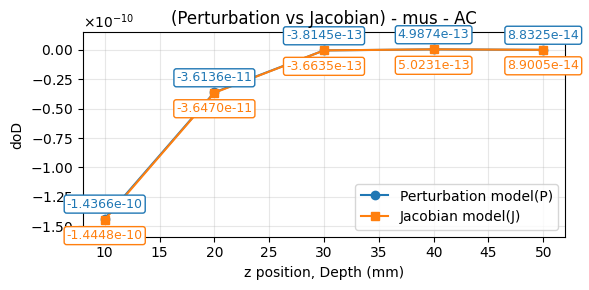

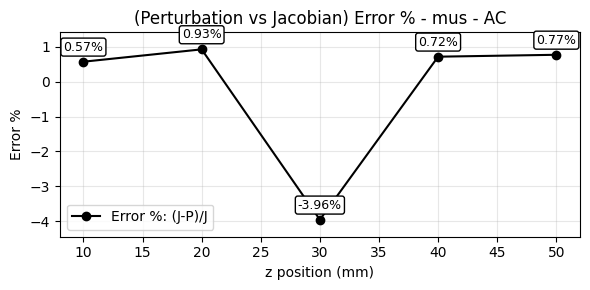

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Data
i = 10
z_positions = [i, 2*i, 3*i, 4*i, 5*i]
x = np.array(z_positions, dtype=float)
y_pert = np.array([doD_mus_pert[60-i],doD_mus_pert[60-2*i],doD_mus_pert[60-3*i],doD_mus_pert[60-4*i],doD_mus_pert[60-5*i]], dtype=float)
y_jac  = np.array([doD_mus_jacobian[60-i],doD_mus_jacobian[60-2*i],doD_mus_jacobian[60-3*i],doD_mus_jacobian[60-4*i],doD_mus_jacobian[60-5*i]], dtype=float)

# Plot
plt.figure(figsize=(6, 3))
line1, = plt.plot(x, y_pert, marker='o', linewidth=1.5, label='Perturbation model(P)')
line2, = plt.plot(x, y_jac,  marker='s', linewidth=1.5, label='Jacobian model(J)')

# Scientific notation for small values
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))

# Zoom y-limits with padding
y_min = min(np.min(y_pert), np.min(y_jac))
y_max = max(np.max(y_pert), np.max(y_jac))
pad = 0.1 * (y_max - y_min)
plt.ylim(y_min - pad, y_max + pad)

# Annotations: values at each point, colored by series and offset to avoid overlap
c1 = line1.get_color()
c2 = line2.get_color()

for xi, yi in zip(x, y_pert):
    ax.annotate(f'{yi:.4e}', (xi, yi),
                textcoords='offset points', xytext=(0, 8), ha='center',
                color=c1, fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=c1, alpha=1))

for xi, yi in zip(x, y_jac):
    ax.annotate(f'{yi:.4e}', (xi, yi),
                textcoords='offset points', xytext=(0, -14), ha='center',
                color=c2, fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=c2, alpha=1))

plt.xlabel('z position, Depth (mm)')
plt.ylabel('doD')
plt.title('(Perturbation vs Jacobian) - mus - AC')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()




# Error Plot
y_error = np.array([error_mus[60-i],error_mus[60-2*i],error_mus[60-3*i],error_mus[60-4*i],error_mus[60-5*i]])

plt.figure(figsize=(6, 3))
line_err, = plt.plot(x, y_error, marker='o', linewidth=1.5, color='black', label='Error %: (J-P)/J')
# Zoom in around the min/max range with 10% padding
y_min = np.min(y_error)
y_max = np.max(y_error)
pad = 0.1 * (y_max - y_min)
plt.ylim(y_min - pad, y_max + pad)

# Get the line color
c_err = line_err.get_color()

# Annotate each point
for xi, yi in zip(x, y_error):
    plt.annotate(f'{yi:.2f}%', (xi, yi),
                 textcoords='offset points', xytext=(0, 8), ha='center',
                 color=c_err, fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=c_err, alpha=1))

plt.xlabel('z position (mm)')
plt.ylabel('Error %')
plt.title('(Perturbation vs Jacobian) Error % - mus - AC')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

